In [1]:
import sys
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config, repair_coord
from utils_energy_analysis import *

In [2]:
lake = 'lucerne'
model = f'{lake}_2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('..//config.json', model)
dx = 100
ds = repair_coord(ds, dx)

In [3]:
def plot_map_quiver(ax, X, Y, U, V, subsetting_factor=4, scale_arrow=5, scale_cmap=0.2):
    X_trimmed = X[::subsetting_factor]
    Y_trimmed = Y[::subsetting_factor]
    U_trimmed = U[::subsetting_factor,::subsetting_factor] #[:,1:]
    V_trimmed = V[::subsetting_factor,::subsetting_factor] #[1:,:]

    U_trimmed = U_trimmed.where(U_trimmed != 0, np.nan)
    V_trimmed = V_trimmed.where(V_trimmed != 0, np.nan)

    U.plot(ax=ax, cmap='RdBu_r', vmin=-scale_cmap, vmax=scale_cmap, cbar_kwargs={'label': 'U [m/s]'})
    ax.quiver(X_trimmed, Y_trimmed, U_trimmed, V_trimmed, scale=scale_arrow, width=0.001)

In [4]:
tt=-1
u = ds.UVEL.isel(time=tt, Z=0)
v = ds.VVEL.isel(time=tt, Z=0)

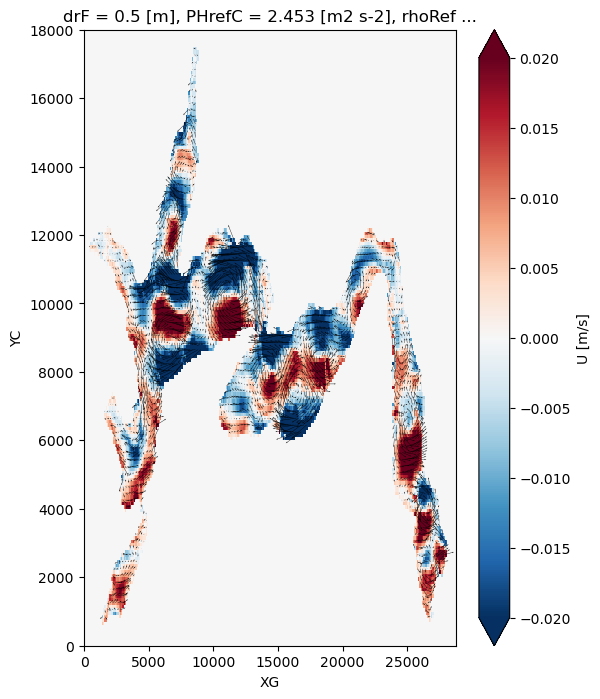

In [5]:
fig, axs = plt.subplots(1,1, figsize=(6,8))
plot_map_quiver(axs, u.XG, u.YC, u, v, subsetting_factor=2, scale_arrow=1, scale_cmap=0.02)

## Continuous Wavelet Transform

In [6]:
import numpy as np
from scipy.fft import fft2, ifft2, fftfreq


def cwt2d_mexican_hat(field, dx, scales):
    """
    2D Continuous Wavelet Transform using the isotropic Mexican Hat wavelet.

    Parameters
    ----------
    field : (ny, nx) ndarray
        Input scalar field.
        NaNs should already be filled or masked.

    dx : float
        Grid spacing [m].

    scales : 1D ndarray
        Wavelet scales [m].

    Returns
    -------
    coeffs : ndarray
        Wavelet coefficients
        shape = (nscale, ny, nx)
    """

    ny, nx = field.shape

    # Fourier frequencies
    kx = 2 * np.pi * fftfreq(nx, d=dx)
    ky = 2 * np.pi * fftfreq(ny, d=dx)

    KX, KY = np.meshgrid(kx, ky)

    K2 = KX**2 + KY**2

    F = fft2(field)

    coeffs = np.empty((len(scales), ny, nx), dtype=np.float64)

    for i, a in enumerate(scales):

        # Mexican Hat in Fourier space
        psi_hat = (a**2 * K2) * np.exp(-0.5 * a**2 * K2)

        coeffs[i] = np.real(ifft2(F * psi_hat))

    return coeffs

In [7]:
def velocity_wavelet_spectrum(u, v, dx, scales):
    """
    Wavelet kinetic energy spectrum.

    Parameters
    ----------
    u,v : 2D arrays

    Returns
    -------
    spectrum
    """

    water = np.isfinite(u) & np.isfinite(v)

    u = np.nan_to_num(u)
    v = np.nan_to_num(v)

    Wu = cwt2d_mexican_hat(u, dx, scales)
    Wv = cwt2d_mexican_hat(v, dx, scales)

    spectrum = np.zeros(len(scales))

    for i in range(len(scales)):

        power = 0.5 * (Wu[i]**2 + Wv[i]**2)

        spectrum[i] = np.mean(power[water])

    return spectrum

In [8]:
u = ds.UVEL.isel(time=0, Z=10).values
v = ds.VVEL.isel(time=0, Z=10).values

dx = 100

scales = np.logspace(
    np.log10(200),
    np.log10(10000),
    50,
)

spectrum = velocity_wavelet_spectrum(
    u,
    v,
    dx,
    scales,
)

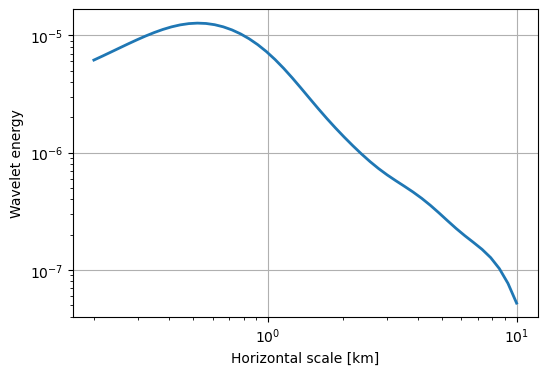

In [9]:
plt.figure(figsize=(6,4))

plt.loglog(
    scales/1000,
    spectrum,
    lw=2,
)

plt.xlabel("Horizontal scale [km]")
plt.ylabel("Wavelet energy")

plt.grid(True)

plt.show()

## Applying over time

In [10]:
S = []

for t in range(4000,4200):
    print(f"Processing time {t}/{ds.sizes['time']}...")
    u = ds.UVEL.isel(time=t, Z=0).values
    v = ds.VVEL.isel(time=t, Z=0).values

    S.append(
        velocity_wavelet_spectrum(
            u,
            v,
            dx,
            scales,
        )
    )

S = np.asarray(S)

Processing time 4000/8760...
Processing time 4001/8760...
Processing time 4002/8760...
Processing time 4003/8760...
Processing time 4004/8760...
Processing time 4005/8760...
Processing time 4006/8760...
Processing time 4007/8760...
Processing time 4008/8760...
Processing time 4009/8760...
Processing time 4010/8760...
Processing time 4011/8760...
Processing time 4012/8760...
Processing time 4013/8760...
Processing time 4014/8760...
Processing time 4015/8760...
Processing time 4016/8760...
Processing time 4017/8760...
Processing time 4018/8760...
Processing time 4019/8760...
Processing time 4020/8760...
Processing time 4021/8760...
Processing time 4022/8760...
Processing time 4023/8760...
Processing time 4024/8760...
Processing time 4025/8760...
Processing time 4026/8760...
Processing time 4027/8760...
Processing time 4028/8760...
Processing time 4029/8760...
Processing time 4030/8760...
Processing time 4031/8760...
Processing time 4032/8760...
Processing time 4033/8760...
Processing tim

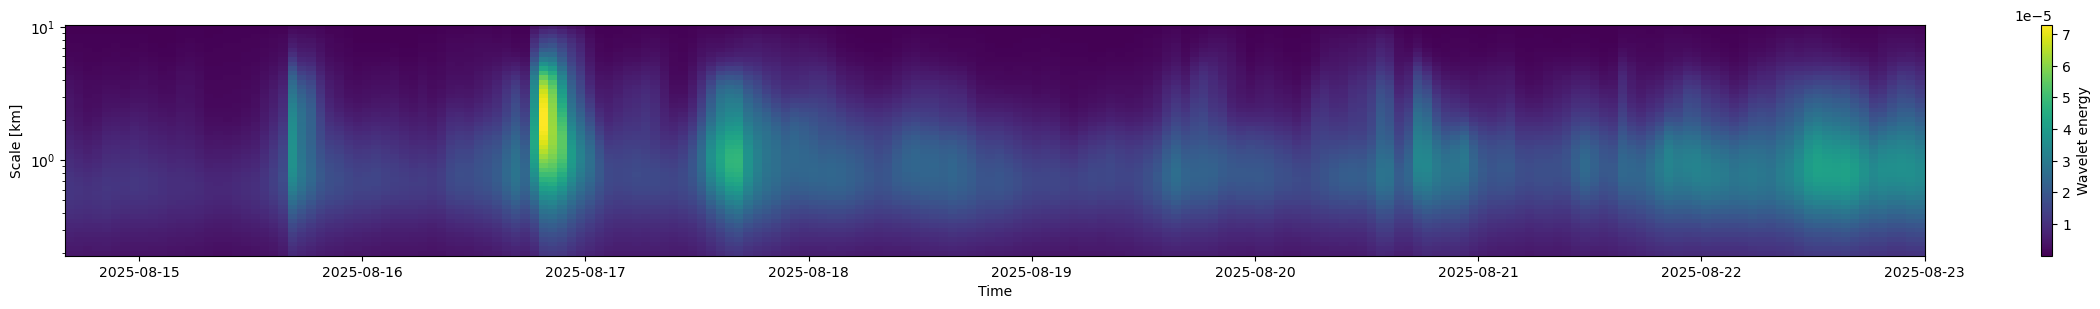

In [16]:
plt.figure(figsize=(30,3))
plt.pcolormesh(
    ds.time[4000:4200],
    scales/1000,
    S.T,
    shading="nearest"
)

plt.yscale("log")

plt.ylabel("Scale [km]")
plt.xlabel("Time")

plt.colorbar(label="Wavelet energy")